In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

cv2.__version__

'4.9.0'

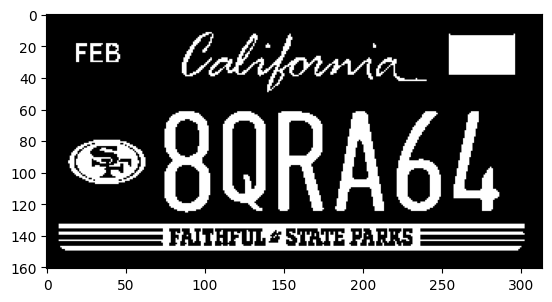

In [2]:
image = cv2.imread("licenseplate.png")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, bin_image = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)
bin_image = cv2.bitwise_not(bin_image)

plt.imshow(bin_image, "gray")

In [3]:
kernel = np.ones((4, 4), np.uint8)
kernel

array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1]], dtype=uint8)

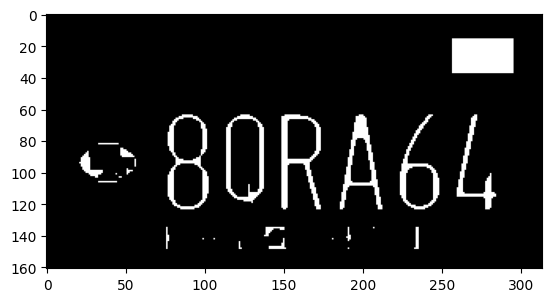

In [4]:
erosion = cv2.erode(bin_image, kernel, iterations=1)
plt.imshow(erosion, cmap="gray")

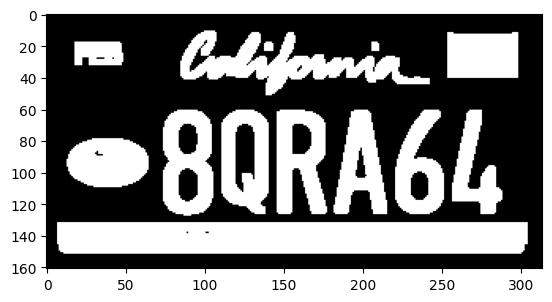

In [5]:
dilation = cv2.dilate(bin_image, kernel, iterations=1)
plt.imshow(dilation, cmap="gray")

In [6]:
kernel1 = [[0, 1, 1, 0], [1, 1, 1, 1], [1, 1, 1, 1], [0, 1, 1, 0]]
kernel1 = np.array(kernel1, np.uint8)
kernel1

array([[0, 1, 1, 0],
       [1, 1, 1, 1],
       [1, 1, 1, 1],
       [0, 1, 1, 0]], dtype=uint8)

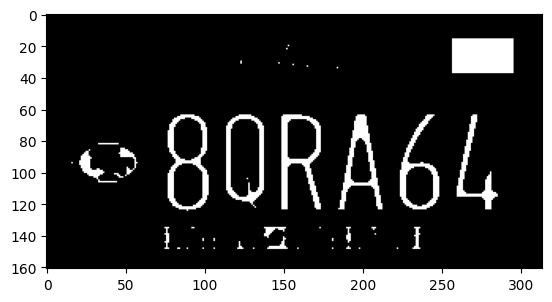

In [7]:
erosion = cv2.erode(bin_image, kernel1, iterations=1)
plt.imshow(erosion, cmap="gray")

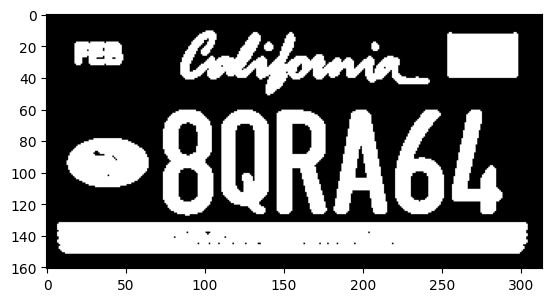

In [8]:
dilation = cv2.dilate(bin_image, kernel1, iterations=1)
plt.imshow(dilation, cmap="gray")

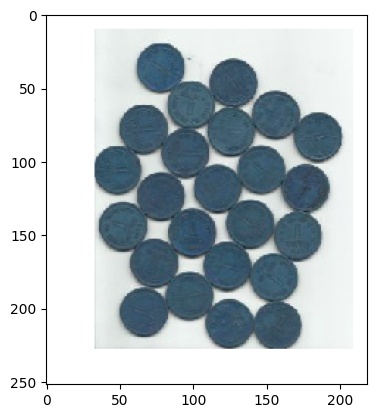

In [42]:
coin = cv2.imread("coin.png")
plt.imshow(coin)

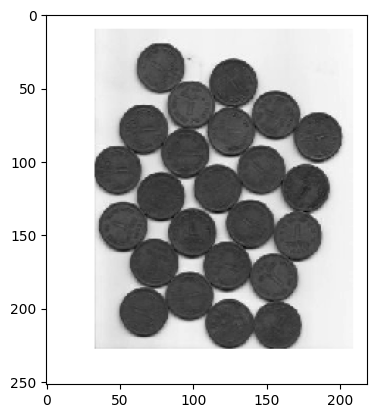

In [43]:
coin_gray = cv2.cvtColor(coin, cv2.COLOR_BGR2GRAY)
plt.imshow(coin_gray, "gray")

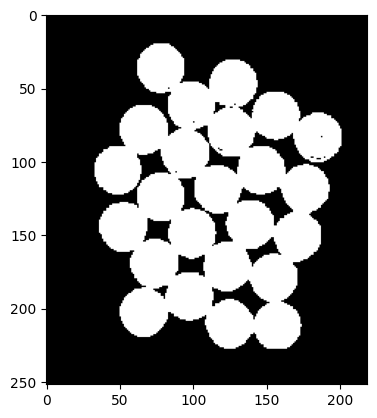

In [44]:
_, bin_img = cv2.threshold(coin_gray, 120, 255, cv2.THRESH_BINARY_INV)
plt.imshow(bin_img, "gray")

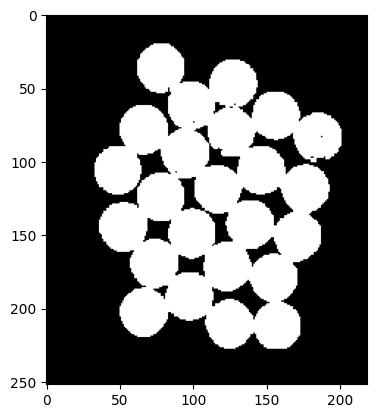

In [45]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
bin_img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel, iterations=1)
plt.imshow(bin_img, "gray")

Text(0.5, 1.0, 'Sure Background')

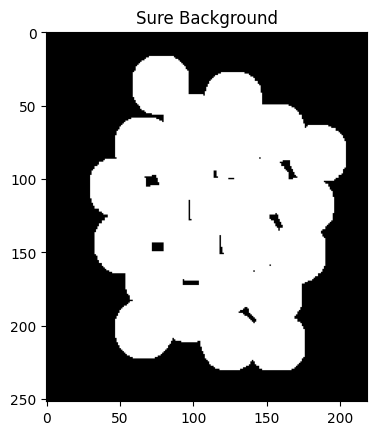

In [46]:
sure_bg = cv2.dilate(bin_img, kernel, iterations=3)
plt.imshow(sure_bg, "gray")
plt.title("Sure Background")

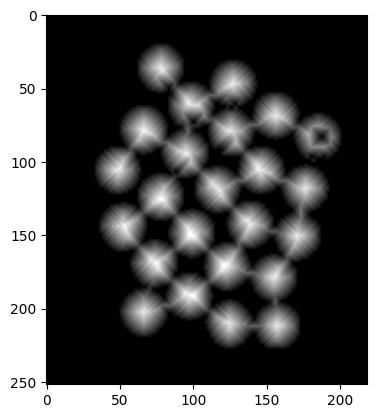

In [47]:
dist = cv2.distanceTransform(bin_img, cv2.DIST_C, 5)
plt.imshow(dist, "gray")

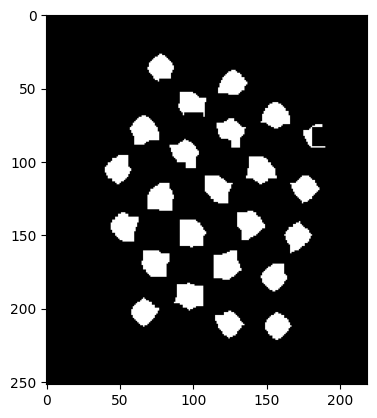

In [48]:
ret, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, cv2.THRESH_BINARY)
sure_fg = sure_fg.astype(np.uint8)
plt.imshow(sure_fg, "gray")

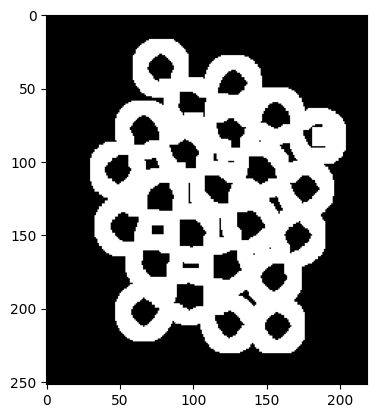

In [50]:
unknown = cv2.subtract(sure_bg, sure_fg)
plt.imshow(unknown, "gray")

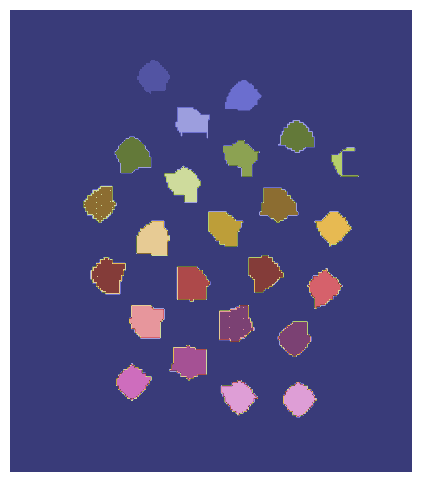

In [51]:
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that background is not 0, but 1
markers += 1
# mark the region of unknown with zero
markers[unknown == 255] = 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(markers, cmap="tab20b")
ax.axis("off")
plt.show()

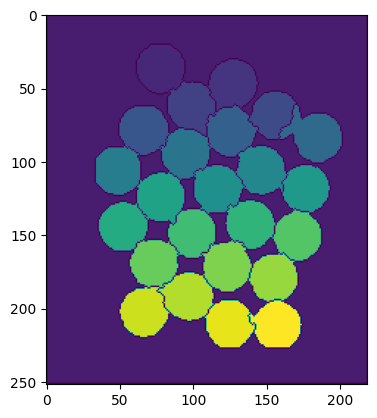

In [53]:
markers = cv2.watershed(coin, markers)
plt.imshow(markers)